In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Expected Sideout Project EDA
Looking at the data before performing any model training

Step 1: Data Cleaning

In [31]:
# load datasert
df = pd.read_csv("combined_dvw.csv")
df

,match_id,point_id,video_time,team,player_number,player_name,player_id,skill_type,evaluation_code,evaluation,...,team_id,point_won_by,winning_attack,serving_team,phase,home_score,visiting_score,set_player_id,reception_quality,point_differential
0,e44723e981facc1e424b615fb599ecc8,84,3607,Northwestern University,NaN,NaN,NaN,NaN,NaN,NaN,...,102.0,"University of California, San Diego",False,Northwestern University,NaN,18,20,NaN,"Positive, attack",-2
1,e44723e981facc1e424b615fb599ecc8,84,3607,Northwestern University,NaN,NaN,NaN,NaN,NaN,NaN,...,102.0,"University of California, San Diego",False,Northwestern University,NaN,18,20,NaN,"Positive, attack",-2
2,e44723e981facc1e424b615fb599ecc8,84,3607,"University of California, San Diego",NaN,NaN,NaN,NaN,NaN,NaN,...,1378.0,"University of California, San Diego",False,Northwestern University,NaN,18,20,NaN,"Positive, attack",-2
3,e44723e981facc1e424b615fb599ecc8,84,3607,"University of California, San Diego",NaN,NaN,NaN,NaN,NaN,NaN,...,1378.0,"University of California, San Diego",False,Northwestern University,NaN,18,20,NaN,"Positive, attack",-2
4,e44723e981facc1e424b615fb599ecc8,84,3607,Northwestern University,11.0,Ayah Elnady,-550456.0,Jump-float serve,-,"Negative, opponent free attack",...,102.0,"University of California, San Diego",False,Northwestern University,Serve,18,20,NaN,"Positive, attack",-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370633,f885acaa3730cfae5d3d4b3a95f772e3,67,4455,Seattle University,NaN,NaN,NaN,NaN,NaN,NaN,...,351.0,Seattle University,False,Seattle University,NaN,14,14,NaN,"Poor, no attack",0
370634,f885acaa3730cfae5d3d4b3a95f772e3,67,4455,"California State University, Fullerton",NaN,NaN,NaN,NaN,NaN,NaN,...,109.0,Seattle University,False,Seattle University,NaN,14,14,NaN,"Poor, no attack",0
370635,f885acaa3730cfae5d3d4b3a95f772e3,67,4455,"California State University, Fullerton",NaN,NaN,NaN,NaN,NaN,NaN,...,109.0,Seattle University,False,Seattle University,NaN,14,14,NaN,"Poor, no attack",0
370636,f885acaa3730cfae5d3d4b3a95f772e3,67,4455,Seattle University,1.0,Anae Asuncion,-512877.0,Jump-float serve,/,"Positive, no attack",...,351.0,Seattle University,False,Seattle University,Serve,14,14,NaN,"Poor, no attack",0


In [32]:
# clean and saved to ucsd_wvb_reception_cleaned.csv
# ucsd_wvb_reception_cleaned.csv will be used for the rest of the notebook
ucsd_name = "University of California, San Diego"

df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
)

text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df = df.replace({"nan": np.nan, "None": np.nan, "": np.nan})

df_ucsd = df[
    (df["home_team"] == ucsd_name) |
    (df["visiting_team"] == ucsd_name) |
    (df["team"] == ucsd_name)
].copy()

df_ucsd["is_ucsd_home"] = df_ucsd["home_team"] == ucsd_name
df_ucsd["home_away"] = np.where(df_ucsd["is_ucsd_home"], "Home", "Away")
df_ucsd["opponent"] = np.where(
    df_ucsd["home_team"] == ucsd_name,
    df_ucsd["visiting_team"],
    df_ucsd["home_team"]
)

reception_mask = df_ucsd["skill_type"].str.contains("reception", case=False, na=False)
df_recv = df_ucsd[reception_mask].copy()

df_recv = df_recv[df_recv["team"] == ucsd_name].copy()

df_recv["sideout"] = (df_recv["point_won_by"] == ucsd_name).astype(int)

df_recv["rotation"] = np.where(
    df_recv["team"] == df_recv["home_team"],
    df_recv["home_setter_position"],
    df_recv["visiting_setter_position"]
)

df_recv["team_score"] = np.where(
    df_recv["team"] == df_recv["home_team"],
    df_recv["home_score"],
    df_recv["visiting_score"]
)

df_recv["opp_score"] = np.where(
    df_recv["team"] == df_recv["home_team"],
    df_recv["visiting_score"],
    df_recv["home_score"]
)

df_recv["score_diff"] = df_recv["team_score"] - df_recv["opp_score"]

df_recv["server_team"] = df_recv["serving_team"]
df_recv["receiving_team"] = df_recv["team"]

df_recv["pass_quality_raw"] = df_recv["reception_quality"].fillna(df_recv["evaluation"])

pass_map = {
    "Perfect pass": "Perfect",
    "Positive, attack": "Positive",
    "OK, no first tempo possible": "OK",
    "Negative, limited attack": "Negative",
    "Poor, no attack": "Poor",
    "Error": "Error"
}

df_recv["pass_grade"] = df_recv["pass_quality_raw"].map(pass_map)
df_recv["pass_grade"] = pd.Categorical(
    df_recv["pass_grade"],
    categories=["Perfect", "Positive", "OK", "Negative", "Poor", "Error"],
    ordered=True
)

df_recv["set_number"] = pd.to_numeric(df_recv["set_number"], errors="coerce")
df_recv["rotation"] = pd.to_numeric(df_recv["rotation"], errors="coerce")
df_recv["player_number"] = pd.to_numeric(df_recv["player_number"], errors="coerce")
df_recv["team_score"] = pd.to_numeric(df_recv["team_score"], errors="coerce")
df_recv["opp_score"] = pd.to_numeric(df_recv["opp_score"], errors="coerce")
df_recv["score_diff"] = pd.to_numeric(df_recv["score_diff"], errors="coerce")
df_recv["point_differential"] = pd.to_numeric(df_recv["point_differential"], errors="coerce")

df_recv["player_name"] = df_recv["player_name"].str.title()
df_recv["team"] = df_recv["team"].str.strip()
df_recv["opponent"] = df_recv["opponent"].str.strip()

df_recv = df_recv.drop_duplicates(subset=["match_id", "point_id", "team", "player_name", "skill_type"])

cols_to_keep = [
    "match_id",
    "point_id",
    "video_time",
    "team",
    "opponent",
    "home_away",
    "set_number",
    "team_score",
    "opp_score",
    "score_diff",
    "point_differential",
    "rotation",
    "player_name",
    "player_number",
    "player_id",
    "skill_type",
    "evaluation_code",
    "evaluation",
    "reception_quality",
    "pass_quality_raw",
    "pass_grade",
    "serving_team",
    "point_won_by",
    "sideout",
    "set_player_id",
    "team_touch_id",
    "phase"
]

clean_df = df_recv[cols_to_keep].copy()

clean_df = clean_df.sort_values(["match_id", "point_id"]).reset_index(drop=True)

print("Cleaned shape:", clean_df.shape)
print(clean_df.head())
print("\nSideout rate:", clean_df["sideout"].mean())
print("\nPass grade counts:")
print(clean_df["pass_grade"].value_counts(dropna=False))
print("\nRotation counts:")
print(clean_df["rotation"].value_counts(dropna=False).sort_index())

clean_df.to_csv("ucsd_wvb_reception_cleaned.csv", index=False)

Cleaned shape: (1023, 27)
                           match_id  point_id  video_time  \
0  01ff8dab997fc5fe1041f1a821bb1682        48        2308   
1  01ff8dab997fc5fe1041f1a821bb1682        49        2331   
2  01ff8dab997fc5fe1041f1a821bb1682        52        2444   
3  01ff8dab997fc5fe1041f1a821bb1682        53        2473   
4  01ff8dab997fc5fe1041f1a821bb1682        54        2782   

                                  team                     opponent home_away  \
0  University of California, San Diego  Northern Arizona University      Away   
1  University of California, San Diego  Northern Arizona University      Away   
2  University of California, San Diego  Northern Arizona University      Away   
3  University of California, San Diego  Northern Arizona University      Away   
4  University of California, San Diego  Northern Arizona University      Away   

   set_number  team_score  opp_score  score_diff  ...  \
0           1          24         24           0  ...   
1     

In [33]:
# This code cleans data, filters it to only UC San Diego reception plays, feature engineers
# useful match-context features like rotation, setter, sideout, score state, opponent, and pass grade
raw_df = pd.read_csv("combined_dvw.csv")

ucsd_name = "University of California, San Diego"

raw_df.columns = (
    raw_df.columns.str.strip()
                  .str.lower()
                  .str.replace(" ", "_")
)

text_cols = raw_df.select_dtypes(include="object").columns
for col in text_cols:
    raw_df[col] = raw_df[col].astype(str).str.strip()

raw_df = raw_df.replace({"nan": np.nan, "None": np.nan, "": np.nan})

ucsd_roster = (
    raw_df[raw_df["team"] == ucsd_name][["player_number", "player_name"]]
    .dropna()
    .drop_duplicates()
)

number_to_name = (
    ucsd_roster.groupby("player_number")["player_name"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

recv_df = raw_df[
    (raw_df["team"] == ucsd_name) &
    (raw_df["skill_type"].str.contains("reception", case=False, na=False))
].copy()

recv_df["rotation"] = np.where(
    recv_df["team"] == recv_df["home_team"],
    recv_df["home_setter_position"],
    recv_df["visiting_setter_position"]
)

def get_setter_number(row):
    if row["team"] == row["home_team"]:
        return row.get(f"home_p{int(row['rotation'])}", np.nan) if pd.notna(row["rotation"]) else np.nan
    else:
        return row.get(f"visiting_p{int(row['rotation'])}", np.nan) if pd.notna(row["rotation"]) else np.nan

recv_df["setter_number"] = recv_df.apply(get_setter_number, axis=1)
recv_df["setter_name"] = recv_df["setter_number"].map(number_to_name)

recv_df["sideout"] = (recv_df["point_won_by"] == ucsd_name).astype(int)

recv_df["team_score"] = np.where(
    recv_df["team"] == recv_df["home_team"],
    recv_df["home_score"],
    recv_df["visiting_score"]
)

recv_df["opp_score"] = np.where(
    recv_df["team"] == recv_df["home_team"],
    recv_df["visiting_score"],
    recv_df["home_score"]
)

recv_df["score_diff"] = recv_df["team_score"] - recv_df["opp_score"]

recv_df["home_away"] = np.where(recv_df["home_team"] == ucsd_name, "Home", "Away")
recv_df["opponent"] = np.where(
    recv_df["home_team"] == ucsd_name,
    recv_df["visiting_team"],
    recv_df["home_team"]
)

pass_map = {
    "Perfect pass": "Perfect",
    "Positive, attack": "Positive",
    "OK, no first tempo possible": "OK",
    "Negative, limited attack": "Negative",
    "Poor, no attack": "Poor",
    "Error": "Error"
}

recv_df["pass_grade"] = recv_df["reception_quality"].map(pass_map)
recv_df["pass_grade"] = pd.Categorical(
    recv_df["pass_grade"],
    categories=["Perfect", "Positive", "OK", "Negative", "Poor", "Error"],
    ordered=True
)

recv_df = recv_df.drop_duplicates(subset=["match_id", "point_id", "team", "player_name", "skill_type"])

clean_df = recv_df.copy()

In [34]:
# helper function for sideouts
def sideout_summary(df, group_col, min_n=1, sort_by_rate=True):
    summary = (
        df.groupby(group_col, dropna=False)
          .agg(
              receptions=("sideout", "size"),
              sideout_rate=("sideout", "mean")
          )
          .reset_index()
    )
    
    summary = summary[summary["receptions"] >= min_n].copy()
    summary["sideout_rate"] = summary["sideout_rate"] * 100
    
    if sort_by_rate:
        summary = summary.sort_values("sideout_rate", ascending=False)
    
    return summary

   rotation  receptions  sideout_rate
0       1.0         178     48.314607
1       2.0         157     53.503185
2       3.0         155     48.387097
3       4.0         183     47.540984
4       5.0         181     50.828729
5       6.0         169     56.213018


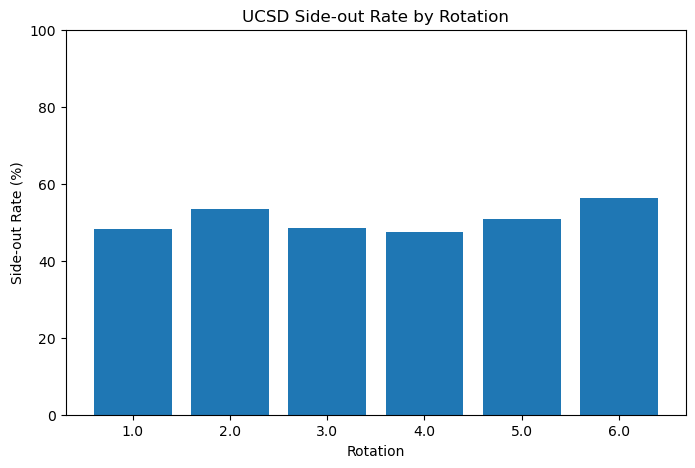

In [35]:
# plot displaying the sideout ratio given the rotation the team is in
rotation_summary = (
    clean_df.groupby("rotation")
    .agg(
        receptions=("sideout", "size"),
        sideout_rate=("sideout", "mean")
    )
    .reset_index()
    .sort_values("rotation")
)

rotation_summary["sideout_rate"] = rotation_summary["sideout_rate"] * 100
print(rotation_summary)

plt.figure(figsize=(8, 5))
plt.bar(rotation_summary["rotation"].astype(str), rotation_summary["sideout_rate"])
plt.xlabel("Rotation")
plt.ylabel("Side-out Rate (%)")
plt.title("UCSD Side-out Rate by Rotation")
plt.ylim(0, 100)
plt.show()

              player_name  receptions  sideout_rate
11        Molly McCluskey          15     53.333333
8   Maria Fernanda Afonso         161     52.795031
5            Kayla Uhlick         227     52.422907
0          Ireland McNees         238     49.579832
12        Paulina Baillie         249     48.995984
1              Iris Canko          45     48.888889
13        Stefania Alupei          60     46.666667


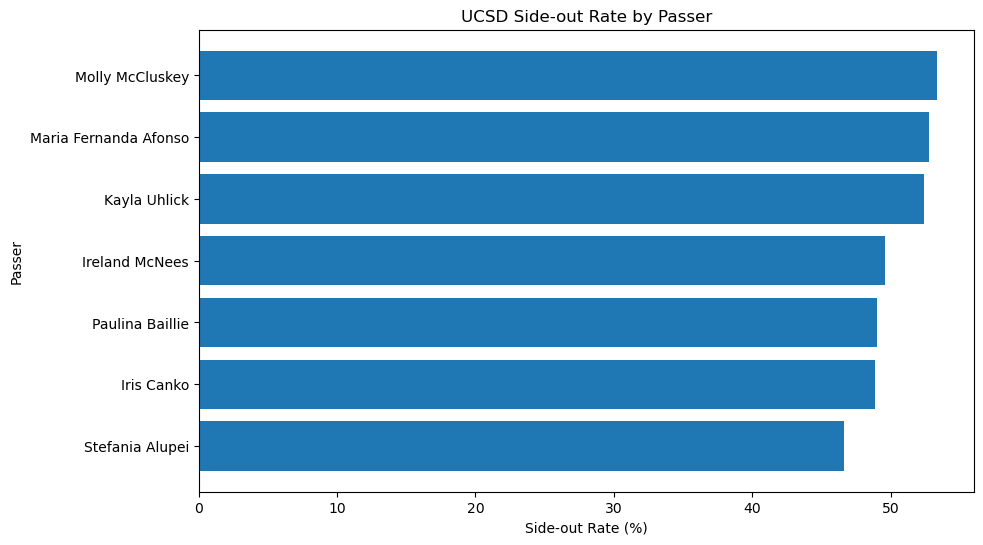

In [36]:
# displays sideout rate given the passer on the UCSD team
passer_summary = sideout_summary(clean_df, "player_name", min_n=15, sort_by_rate=True)
print(passer_summary)

plt.figure(figsize=(10, 6))
plt.barh(passer_summary["player_name"].astype(str), passer_summary["sideout_rate"])
plt.xlabel("Side-out Rate (%)")
plt.ylabel("Passer")
plt.title("UCSD Side-out Rate by Passer")
plt.gca().invert_yaxis()
plt.show()

    setter_name  receptions  sideout_rate
1  Maija Nepszy         548     50.364964
3     Mika Rome         452     50.221239


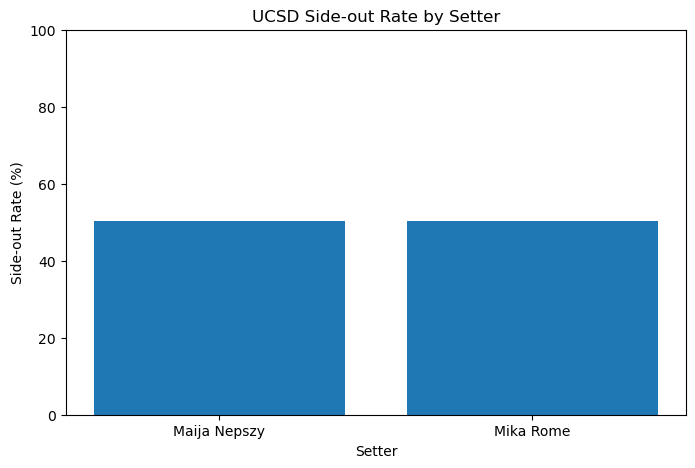

In [37]:
# returns the sideout rate given the setter of the UCSD team
setter_summary = sideout_summary(clean_df, "setter_name", min_n=15, sort_by_rate=True)

print(setter_summary)

plt.figure(figsize=(8, 5))
plt.bar(setter_summary["setter_name"].astype(str), setter_summary["sideout_rate"])
plt.xlabel("Setter")
plt.ylabel("Side-out Rate (%)")
plt.title("UCSD Side-out Rate by Setter")
plt.ylim(0, 100)
plt.show()

In [38]:
# sideout rates given a combination of the passer and setter (MAYBE ADD IN COMBINATION OF HITTER LATER AS WELL)
passer_setter_summary = (
    clean_df.groupby(["player_name", "setter_name"])
    .agg(
        receptions=("sideout", "size"),
        sideout_rate=("sideout", "mean")
    )
    .reset_index()
)

passer_setter_summary = passer_setter_summary[passer_setter_summary["receptions"] >= 10].copy()
passer_setter_summary["sideout_rate"] = passer_setter_summary["sideout_rate"] * 100
passer_setter_summary = passer_setter_summary.sort_values("sideout_rate", ascending=False)

print(passer_setter_summary)

              player_name   setter_name  receptions  sideout_rate
18  Maria Fernanda Afonso  Maija Nepszy          81     58.024691
13           Kayla Uhlick     Mika Rome          93     54.838710
3          Ireland McNees     Mika Rome         114     50.000000
11           Kayla Uhlick  Maija Nepszy         131     49.618321
1          Ireland McNees  Maija Nepszy         120     49.166667
6              Iris Canko     Mika Rome          39     48.717949
26        Paulina Baillie  Maija Nepszy         136     47.794118
28        Paulina Baillie     Mika Rome         105     47.619048
19  Maria Fernanda Afonso     Mika Rome          80     47.500000
31        Stefania Alupei  Maija Nepszy          53     45.283019


  pass_grade  receptions  sideout_rate
0    Perfect          64     62.500000
1   Positive         447     59.284116
2         OK         152     57.236842
3   Negative         253     46.640316
4       Poor          50     18.000000
5      Error          57      0.000000


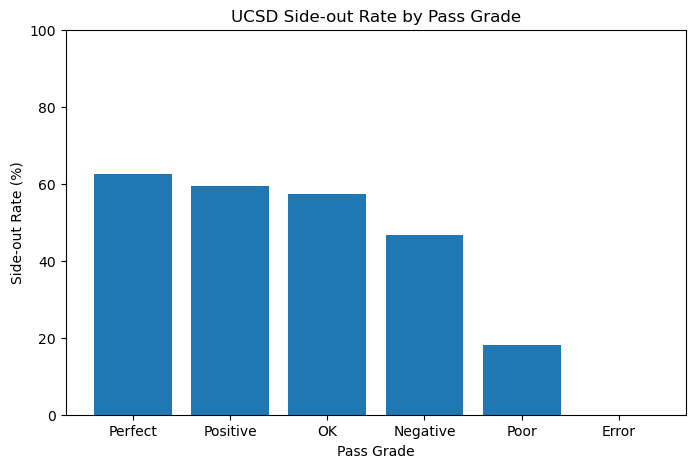

In [39]:
# sideout rate given passing scores
pass_grade_summary = (
    clean_df.groupby("pass_grade", observed=False)
    .agg(
        receptions=("sideout", "size"),
        sideout_rate=("sideout", "mean")
    )
    .reset_index()
)

pass_grade_summary["sideout_rate"] = pass_grade_summary["sideout_rate"] * 100
print(pass_grade_summary)

plt.figure(figsize=(8, 5))
plt.bar(pass_grade_summary["pass_grade"].astype(str), pass_grade_summary["sideout_rate"])
plt.xlabel("Pass Grade")
plt.ylabel("Side-out Rate (%)")
plt.title("UCSD Side-out Rate by Pass Grade")
plt.ylim(0, 100)
plt.show()

   set_number  receptions  sideout_rate
0           1         247     44.129555
1           2         241     52.697095
2           3         302     51.986755
3           4         180     52.222222
4           5          53     60.377358


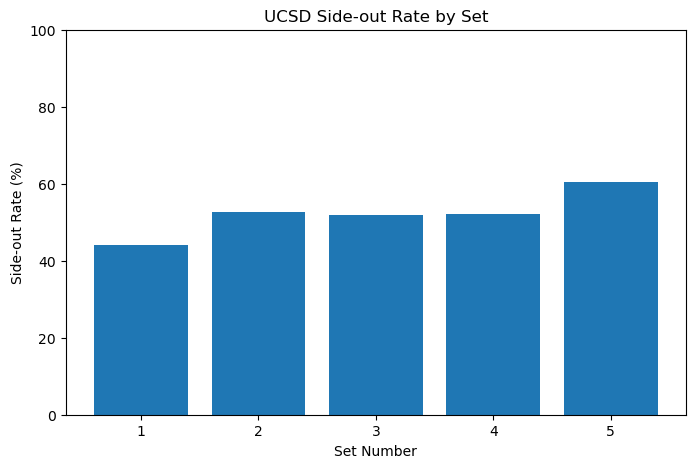

In [40]:
# sideout rate given setting scores
set_summary = (
    clean_df.groupby("set_number")
    .agg(
        receptions=("sideout", "size"),
        sideout_rate=("sideout", "mean")
    )
    .reset_index()
    .sort_values("set_number")
)

set_summary["sideout_rate"] = set_summary["sideout_rate"] * 100
print(set_summary)

plt.figure(figsize=(8, 5))
plt.bar(set_summary["set_number"].astype(str), set_summary["sideout_rate"])
plt.xlabel("Set Number")
plt.ylabel("Side-out Rate (%)")
plt.title("UCSD Side-out Rate by Set")
plt.ylim(0, 100)
plt.show()